In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示（可选）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
df = pd.read_csv('train.csv')  # 确保文件在同一个文件夹
print(df.shape)
df.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# 基本信息
df.info()

# 描述统计
df.describe()

# 缺失值检查
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
# 单变量分析1：生还情况分布
# ============================================

print("\n" + "="*50)
print("1. 生还情况分布")
print("="*50)

survived_dist = df['Survived'].value_counts().sort_index()
survived_pct = df['Survived'].value_counts(normalize=True).sort_index() * 100

result = pd.DataFrame({
    '生还状态': ['遇难(0)', '生还(1)'],
    '人数': survived_dist.values,
    '占比(%)': survived_pct.round(2).values
})
print(result)

# ============================================


1. 生还情况分布
    生还状态   人数  占比(%)
0  遇难(0)  549  61.62
1  生还(1)  342  38.38


In [4]:
# 单变量分析2：性别对生还率的影响
# ============================================

print("\n" + "="*50)
print("2. 性别对生还率的影响")
print("="*50)

gender_analysis = df.groupby('Sex').agg({
    'Survived': ['count', 'sum', 'mean']
}).round(4)

gender_analysis.columns = ['总人数', '生还人数', '生还率']
gender_analysis['生还率(%)'] = (gender_analysis['生还率'] * 100).round(2)
print(gender_analysis)

# ============================================


2. 性别对生还率的影响
        总人数  生还人数     生还率  生还率(%)
Sex                              
female  314   233  0.7420   74.20
male    577   109  0.1889   18.89


In [5]:
# 单变量分析3：舱位等级对生还率的影响
# ============================================

print("\n" + "="*50)
print("3. 舱位等级对生还率的影响")
print("="*50)

pclass_analysis = df.groupby('Pclass').agg({
    'Survived': ['count', 'sum', 'mean']
}).round(4)

pclass_analysis.columns = ['总人数', '生还人数', '生还率']
pclass_analysis['生还率(%)'] = (pclass_analysis['生还率'] * 100).round(2)
print(pclass_analysis)



3. 舱位等级对生还率的影响
        总人数  生还人数     生还率  生还率(%)
Pclass                           
1       216   136  0.6296   62.96
2       184    87  0.4728   47.28
3       491   119  0.2424   24.24


In [6]:
# 单变量分析4：年龄对生还率的影响（含缺失值处理）
# ============================================

print("\n" + "="*50)
print("4. 年龄对生还率的影响")
print("="*50)

# 创建年龄段分组
def age_group(age):
    if pd.isna(age):
        return '未知'
    elif age <= 12:
        return '儿童(0-12)'
    elif age <= 18:
        return '青少年(13-18)'
    elif age <= 35:
        return '青年(19-35)'
    elif age <= 55:
        return '中年(36-55)'
    else:
        return '老年(55+)'

df['AgeGroup'] = df['Age'].apply(age_group)

age_analysis = df.groupby('AgeGroup').agg({
    'Survived': ['count', 'sum', 'mean']
}).round(4)

age_analysis.columns = ['总人数', '生还人数', '生还率']
age_analysis['生还率(%)'] = (age_analysis['生还率'] * 100).round(2)

# 按年龄顺序排列
age_order = ['儿童(0-12)', '青少年(13-18)', '青年(19-35)', '中年(36-55)', '老年(55+)', '未知']
age_analysis = age_analysis.reindex(age_order)
print(age_analysis)

# 年龄缺失值统计
print(f"\n年龄缺失值: {df['Age'].isna().sum()}人, 占比: {(df['Age'].isna().mean()*100):.2f}%")



4. 年龄对生还率的影响
            总人数  生还人数     生还率  生还率(%)
AgeGroup                             
儿童(0-12)     69    40  0.5797   57.97
青少年(13-18)   70    30  0.4286   42.86
青年(19-35)   358   137  0.3827   38.27
中年(36-55)   177    71  0.4011   40.11
老年(55+)      40    12  0.3000   30.00
未知          177    52  0.2938   29.38

年龄缺失值: 177人, 占比: 19.87%


In [7]:
# 单变量分析5：登船港口对生还率的影响
# ============================================

print("\n" + "="*50)
print("5. 登船港口对生还率的影响")
print("="*50)

# 港口缺失值处理
embarked_analysis = df[df['Embarked'].notna()].groupby('Embarked').agg({
    'Survived': ['count', 'sum', 'mean']
}).round(4)

embarked_analysis.columns = ['总人数', '生还人数', '生还率']
embarked_analysis['生还率(%)'] = (embarked_analysis['生还率'] * 100).round(2)

# 添加港口中文名
port_names = {'C': '瑟堡(C)', 'Q': '皇后镇(Q)', 'S': '南安普顿(S)'}
embarked_analysis.index = embarked_analysis.index.map(port_names)
print(embarked_analysis)

# 港口缺失值统计
print(f"\n港口缺失值: {df['Embarked'].isna().sum()}人")

# ============================================
# 汇总对比表
# ============================================

print("\n" + "="*50)
print("汇总：各维度生还率对比")
print("="*50)

summary = pd.DataFrame({
    '分析维度': ['全体', '女性', '男性', '一等舱', '二等舱', '三等舱', 
                '儿童(0-12)', '老年(55+)', '瑟堡(C)', '南安普顿(S)'],
    '生还率(%)': [
        df['Survived'].mean() * 100,
        df[df['Sex']=='female']['Survived'].mean() * 100,
        df[df['Sex']=='male']['Survived'].mean() * 100,
        df[df['Pclass']==1]['Survived'].mean() * 100,
        df[df['Pclass']==2]['Survived'].mean() * 100,
        df[df['Pclass']==3]['Survived'].mean() * 100,
        df[df['Age']<=12]['Survived'].mean() * 100,
        df[df['Age']>55]['Survived'].mean() * 100,
        df[df['Embarked']=='C']['Survived'].mean() * 100,
        df[df['Embarked']=='S']['Survived'].mean() * 100
    ]
}).round(2)

print(summary)


5. 登船港口对生还率的影响
          总人数  生还人数     生还率  生还率(%)
Embarked                           
瑟堡(C)     168    93  0.5536   55.36
皇后镇(Q)     77    30  0.3896   38.96
南安普顿(S)   644   217  0.3370   33.70

港口缺失值: 2人

汇总：各维度生还率对比
       分析维度  生还率(%)
0        全体   38.38
1        女性   74.20
2        男性   18.89
3       一等舱   62.96
4       二等舱   47.28
5       三等舱   24.24
6  儿童(0-12)   57.97
7   老年(55+)   30.00
8     瑟堡(C)   55.36
9   南安普顿(S)   33.70


In [12]:
# ============================================
# Titanic数据可视化探索 - 修复中文显示
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 字体设置 - 自动检测系统可用字体
# ============================================

import matplotlib.font_manager as fm

# 方法1：尝试常见中文字体
def set_chinese_font():
    """自动检测并设置中文字体"""
    
    # Windows常见中文字体
    windows_fonts = ['SimHei', 'Microsoft YaHei', 'SimSun', 'KaiTi']
    # Mac常见中文字体  
    mac_fonts = ['Arial Unicode MS', 'Heiti TC', 'PingFang HK']
    # Linux常见中文字体
    linux_fonts = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'Source Han Sans SC']
    
    all_fonts = windows_fonts + mac_fonts + linux_fonts
    
    # 获取系统可用字体
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    # 找到第一个可用的中文字体
    for font in all_fonts:
        if font in available_fonts:
            print(f"✓ 找到可用中文字体: {font}")
            plt.rcParams['font.sans-serif'] = [font] + plt.rcParams['font.sans-serif']
            plt.rcParams['axes.unicode_minus'] = False
            return font
    
    # 如果都没找到，使用备用方案
    print("⚠ 未找到系统中文字体，使用备用方案")
    print("  建议安装: pip install matplotlib-fontja 或手动下载SimHei字体")
    return None

# 执行字体设置
chinese_font = set_chinese_font()

# 读取数据
df = pd.read_csv('train.csv')

# 创建特征
def age_group(age):
    if pd.isna(age): return '未知'
    elif age <= 12: return '儿童(0-12)'
    elif age <= 18: return '青少年(13-18)'
    elif age <= 35: return '青年(19-35)'
    elif age <= 55: return '中年(36-55)'
    else: return '老年(55+)'

df['AgeGroup'] = df['Age'].apply(age_group)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print(f"数据加载完成: {df.shape[0]}人 × {df.shape[1]}列")


✓ 找到可用中文字体: SimHei
数据加载完成: 891人 × 14列


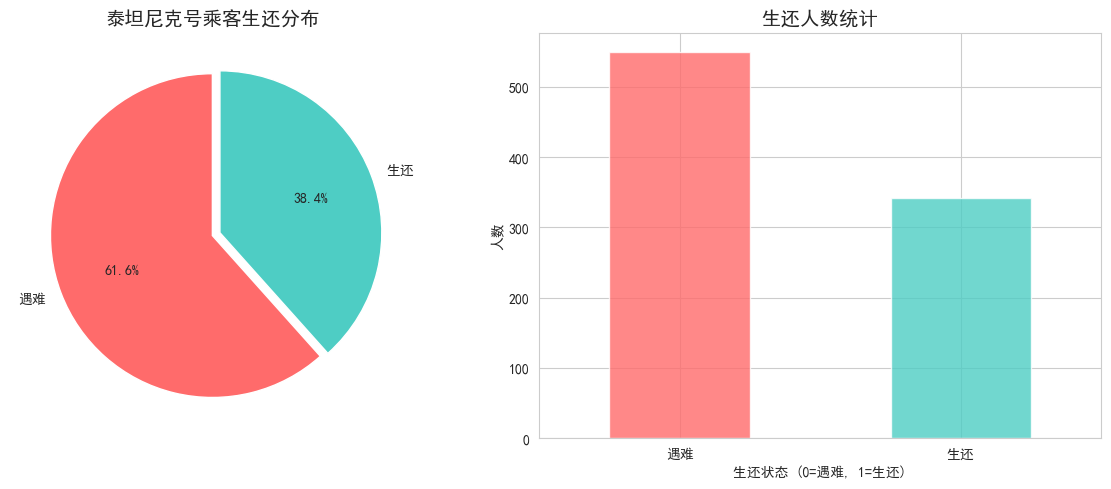

In [13]:
# 可视化1：单变量分布 - 生还情况饼图
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 饼图：生还分布
survived_counts = df['Survived'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
axes[0].pie(survived_counts, labels=['遇难', '生还'], autopct='%1.1f%%', 
            colors=colors, startangle=90, explode=(0, 0.05))
axes[0].set_title('泰坦尼克号乘客生还分布', fontsize=14, fontweight='bold')

# 柱状图：生还人数
survived_counts.plot(kind='bar', ax=axes[1], color=colors, alpha=0.8)
axes[1].set_title('生还人数统计', fontsize=14, fontweight='bold')
axes[1].set_xlabel('生还状态 (0=遇难, 1=生还)')
axes[1].set_ylabel('人数')
axes[1].set_xticklabels(['遇难', '生还'], rotation=0)

plt.tight_layout()
plt.savefig('01_survival_overview.png', dpi=300, bbox_inches='tight')
plt.show()


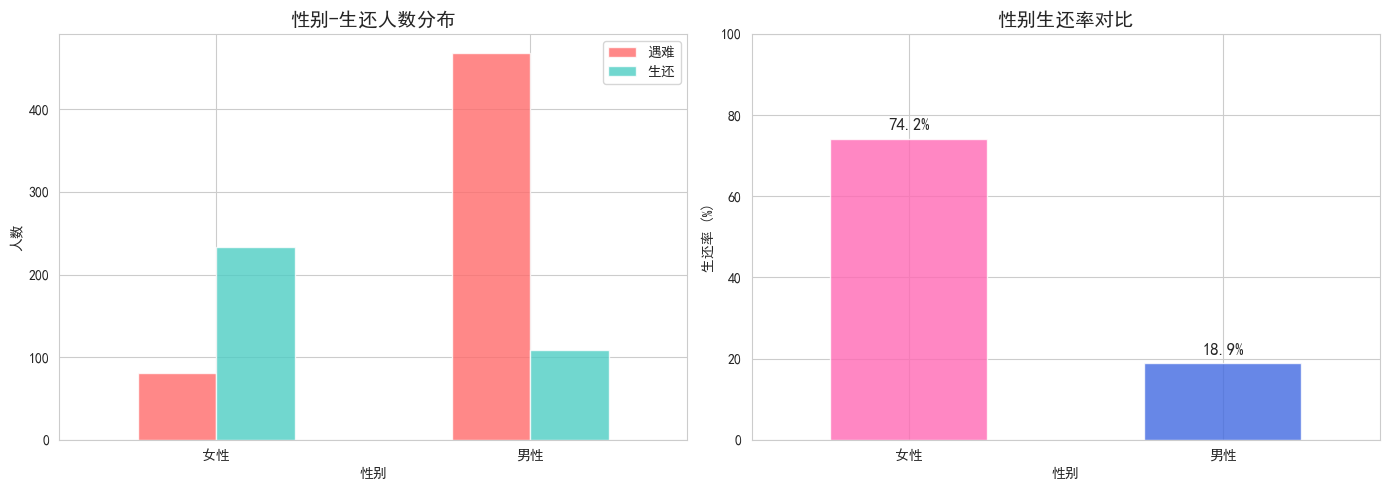

In [14]:
# ============================================
# 可视化2：性别生还率对比 - 分组柱状图
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：按性别分组计数
gender_survival = df.groupby(['Sex', 'Survived']).size().unstack()
gender_survival.plot(kind='bar', ax=axes[0], color=['#ff6b6b', '#4ecdc4'], alpha=0.8)
axes[0].set_title('性别-生还人数分布', fontsize=14, fontweight='bold')
axes[0].set_xlabel('性别')
axes[0].set_ylabel('人数')
axes[0].legend(['遇难', '生还'])
axes[0].set_xticklabels(['女性', '男性'], rotation=0)

# 右图：生还率对比
gender_rate = df.groupby('Sex')['Survived'].mean() * 100
gender_rate.plot(kind='bar', ax=axes[1], color=['#ff69b4', '#4169e1'], alpha=0.8)
axes[1].set_title('性别生还率对比', fontsize=14, fontweight='bold')
axes[1].set_xlabel('性别')
axes[1].set_ylabel('生还率 (%)')
axes[1].set_ylim(0, 100)
axes[1].set_xticklabels(['女性', '男性'], rotation=0)

# 添加数值标签
for i, v in enumerate(gender_rate):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('02_gender_survival.png', dpi=300, bbox_inches='tight')
plt.show()


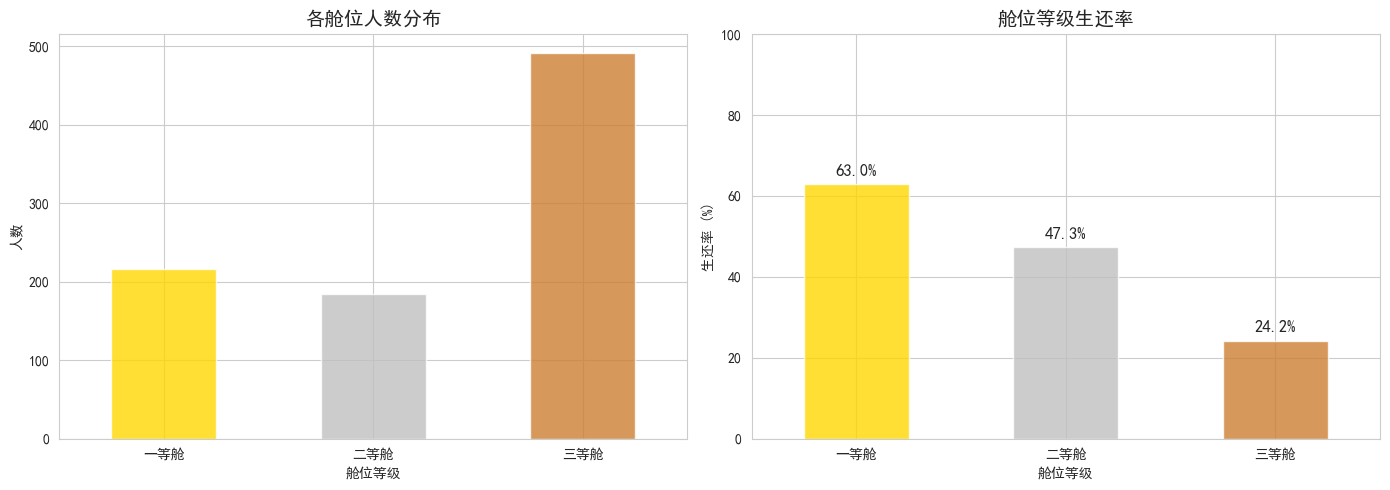

In [15]:
# ============================================
# 可视化3：舱位等级生还率 - 渐变色彩
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各舱位人数分布
pclass_counts = df['Pclass'].value_counts().sort_index()
colors_pclass = ['#ffd700', '#c0c0c0', '#cd7f32']  # 金银铜色
pclass_counts.plot(kind='bar', ax=axes[0], color=colors_pclass, alpha=0.8)
axes[0].set_title('各舱位人数分布', fontsize=14, fontweight='bold')
axes[0].set_xlabel('舱位等级')
axes[0].set_ylabel('人数')
axes[0].set_xticklabels(['一等舱', '二等舱', '三等舱'], rotation=0)

# 右图：各舱位生还率
pclass_rate = df.groupby('Pclass')['Survived'].mean() * 100
pclass_rate.plot(kind='bar', ax=axes[1], color=colors_pclass, alpha=0.8)
axes[1].set_title('舱位等级生还率', fontsize=14, fontweight='bold')
axes[1].set_xlabel('舱位等级')
axes[1].set_ylabel('生还率 (%)')
axes[1].set_ylim(0, 100)
axes[1].set_xticklabels(['一等舱', '二等舱', '三等舱'], rotation=0)

# 添加数值标签
for i, v in enumerate(pclass_rate):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('03_pclass_survival.png', dpi=300, bbox_inches='tight')
plt.show()

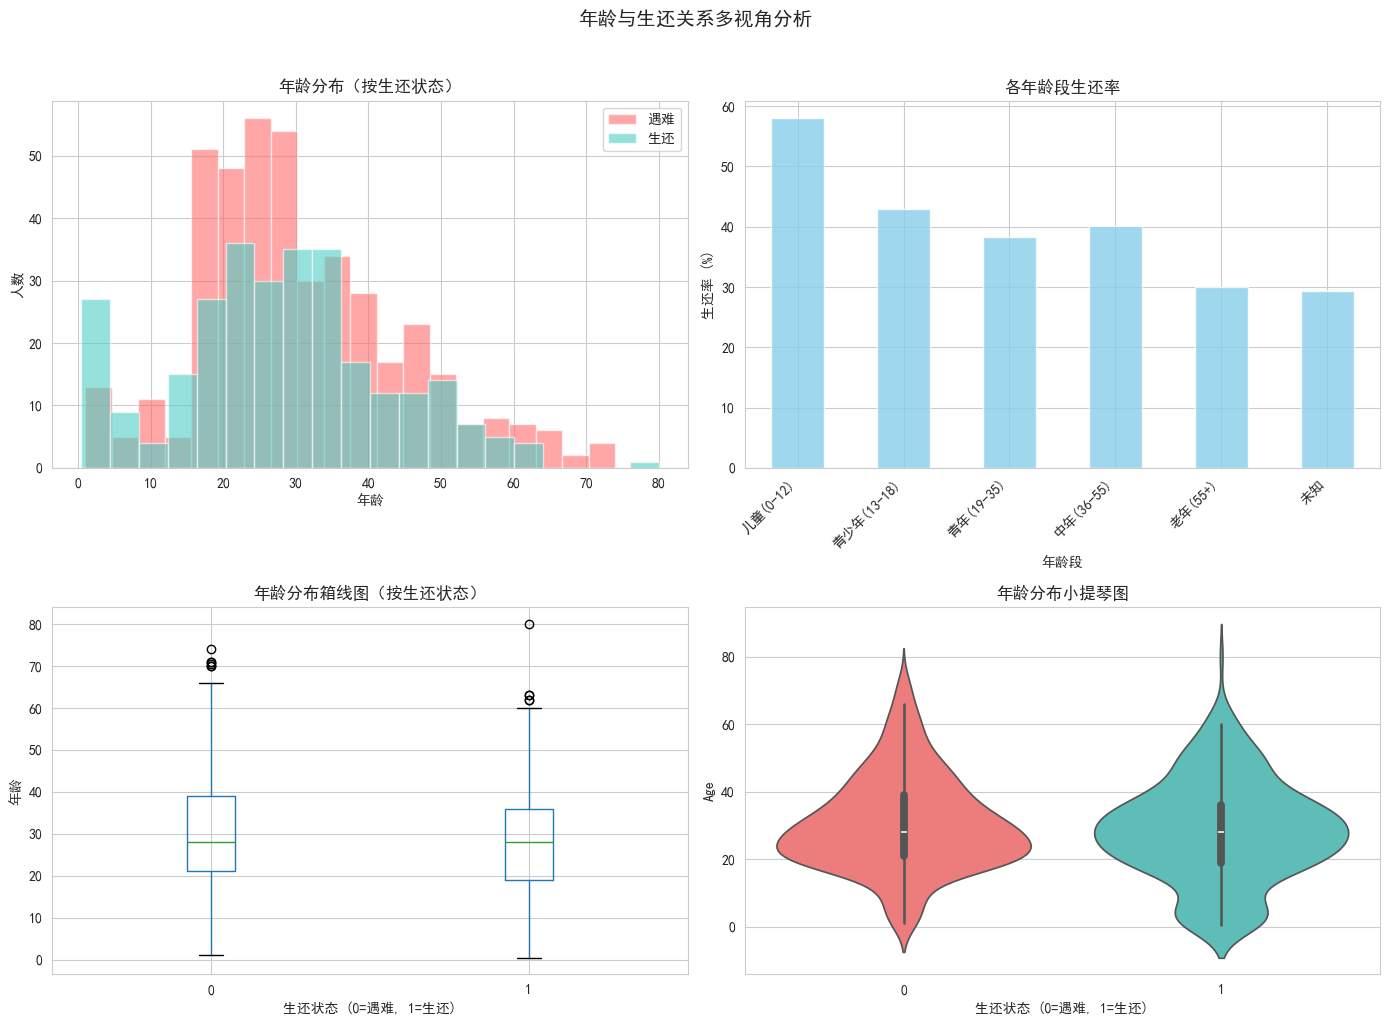

In [16]:
# ============================================
# 可视化4：年龄分布与生还率 - 直方图+箱线图
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 左上：年龄分布直方图（按生还着色）
df[df['Survived']==0]['Age'].dropna().hist(ax=axes[0,0], bins=20, alpha=0.6, 
                                            color='#ff6b6b', label='遇难')
df[df['Survived']==1]['Age'].dropna().hist(ax=axes[0,0], bins=20, alpha=0.6, 
                                            color='#4ecdc4', label='生还')
axes[0,0].set_title('年龄分布（按生还状态）', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('年龄')
axes[0,0].set_ylabel('人数')
axes[0,0].legend()

# 右上：年龄段生还率
age_order = ['儿童(0-12)', '青少年(13-18)', '青年(19-35)', '中年(36-55)', '老年(55+)', '未知']
age_rate = df.groupby('AgeGroup')['Survived'].mean().reindex(age_order) * 100
age_rate.plot(kind='bar', ax=axes[0,1], color='skyblue', alpha=0.8)
axes[0,1].set_title('各年龄段生还率', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('年龄段')
axes[0,1].set_ylabel('生还率 (%)')
axes[0,1].set_xticklabels(age_rate.index, rotation=45, ha='right')

# 左下：年龄箱线图（按生还）
df.boxplot(column='Age', by='Survived', ax=axes[1,0])
axes[1,0].set_title('年龄分布箱线图（按生还状态）', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('生还状态 (0=遇难, 1=生还)')
axes[1,0].set_ylabel('年龄')

# 右下：小提琴图
sns.violinplot(data=df, x='Survived', y='Age', ax=axes[1,1], 
               palette=['#ff6b6b', '#4ecdc4'])
axes[1,1].set_title('年龄分布小提琴图', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('生还状态 (0=遇难, 1=生还)')

plt.suptitle('年龄与生还关系多视角分析', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_age_survival.png', dpi=300, bbox_inches='tight')
plt.show()


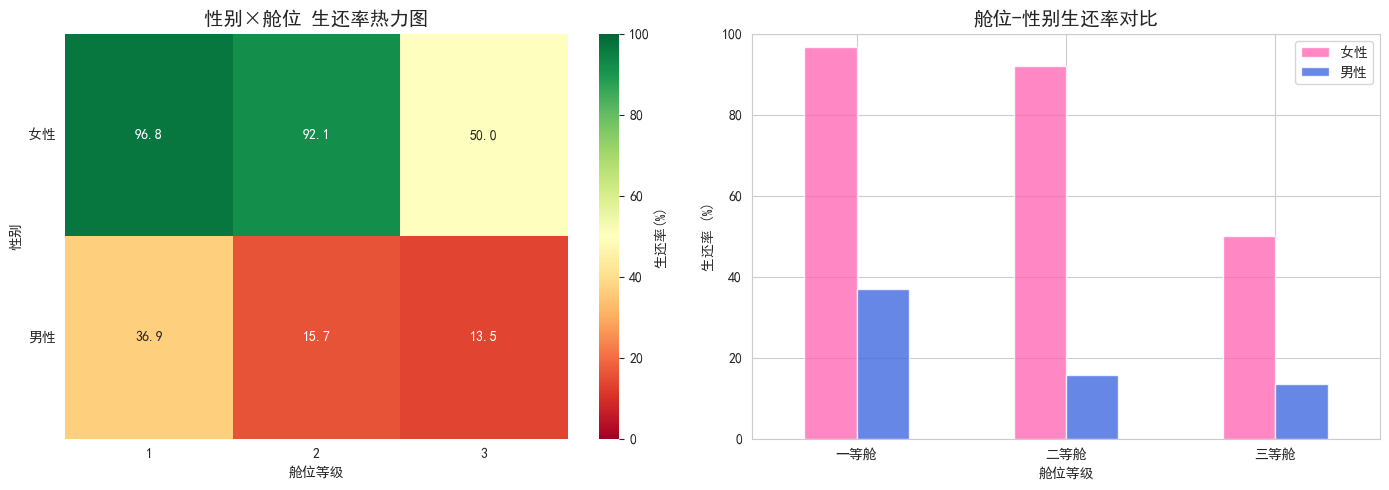

In [20]:
# ============================================
# 可视化5：性别×舱位热力图
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_table = df.pivot_table(values='Survived', index='Sex', 
                              columns='Pclass', aggfunc='mean') * 100
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn', 
            ax=axes[0], vmin=0, vmax=100, cbar_kws={'label': '生还率(%)'})
axes[0].set_title('性别×舱位 生还率热力图', fontsize=14, fontweight='bold')
axes[0].set_xlabel('舱位等级')
axes[0].set_ylabel('性别')
axes[0].set_yticklabels(['女性', '男性'], rotation=0)

gender_pclass = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100
gender_pclass.plot(kind='bar', ax=axes[1], color=['#ff69b4', '#4169e1'], alpha=0.8)
axes[1].set_title('舱位-性别生还率对比', fontsize=14, fontweight='bold')
axes[1].set_xlabel('舱位等级')
axes[1].set_ylabel('生还率 (%)')
axes[1].legend(['女性', '男性'])
axes[1].set_xticklabels(['一等舱', '二等舱', '三等舱'], rotation=0)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('05_gender_pclass_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


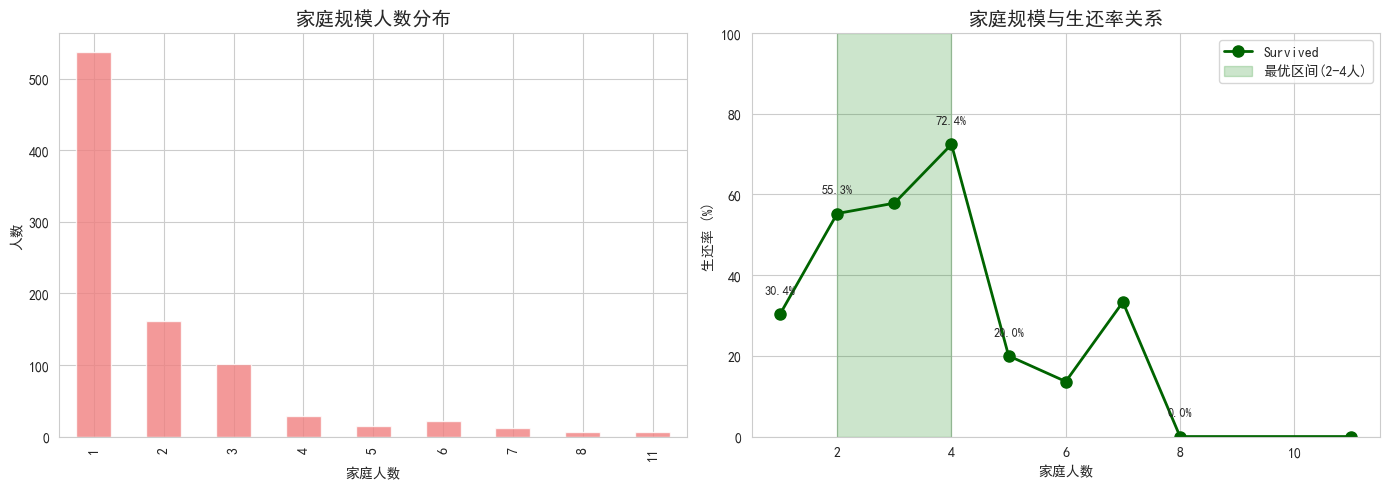


🎉 所有可视化完成！生成文件：
  ✓ 01_survival_overview.png
  ✓ 02_gender_survival.png
  ✓ 03_pclass_survival.png
  ✓ 04_age_survival.png
  ✓ 05_gender_pclass_heatmap.png
  ✓ 06_family_size.png


In [21]:
# ============================================
# 可视化6：家庭规模分析
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

family_counts = df['FamilySize'].value_counts().sort_index()
family_counts.plot(kind='bar', ax=axes[0], color='lightcoral', alpha=0.8)
axes[0].set_title('家庭规模人数分布', fontsize=14, fontweight='bold')
axes[0].set_xlabel('家庭人数')
axes[0].set_ylabel('人数')

family_rate = df.groupby('FamilySize')['Survived'].mean() * 100
family_rate.plot(kind='line', marker='o', ax=axes[1], color='darkgreen', 
                 linewidth=2, markersize=8)
axes[1].set_title('家庭规模与生还率关系', fontsize=14, fontweight='bold')
axes[1].set_xlabel('家庭人数')
axes[1].set_ylabel('生还率 (%)')
axes[1].set_ylim(0, 100)
axes[1].axvspan(2, 4, alpha=0.2, color='green', label='最优区间(2-4人)')
axes[1].legend()

for i, v in family_rate.items():
    if i in [1, 2, 4, 5, 8]:
        axes[1].annotate(f'{v:.1f}%', xy=(i, v), xytext=(i, v+5),
                        ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('06_family_size.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("🎉 所有可视化完成！生成文件：")
print("="*50)
files = ['01_survival_overview.png', '02_gender_survival.png', 
         '03_pclass_survival.png', '04_age_survival.png',
         '05_gender_pclass_heatmap.png', '06_family_size.png']
for f in files:
    print(f"  ✓ {f}")

In [25]:
# ============================================
# SQL vs Pandas 三大核心场景对比
# 场景1: 家庭规模分析（SQL窗口函数）
# 场景2: 环比/排名分析（模拟SQL窗口函数）
# 场景3: 数据透视表（Pandas特色功能）
# ============================================

import pandas as pd
import numpy as np
import time

# 读取数据
df = pd.read_csv('train.csv')
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # 家庭规模

print(f"数据集: {len(df)}行")
print("="*70)

# ============================================
# 场景1: 家庭规模分析（SQL窗口函数 vs Pandas）
# SQL: SUM(Survived) OVER(PARTITION BY FamilySize) 等
# ============================================

print("\n" + "🎯 场景1: 家庭规模分析")
print("-"*50)

# 1.1 基础统计（SQL GROUP BY）
family_basic = df.groupby('FamilySize').agg({
    'Survived': ['count', 'sum', 'mean']
}).round(4)
family_basic.columns = ['总人数', '生还人数', '生还率']
family_basic['生还率(%)'] = (family_basic['生还率'] * 100).round(2)

print("【1.1 基础统计】SQL: GROUP BY FamilySize")
print(family_basic)

# 1.2 窗口函数：家庭规模在全体中的占比（SQL OVER()）
# SQL: COUNT(*) * 100.0 / SUM(COUNT(*)) OVER() as global_pct
family_basic['全局占比(%)'] = (family_basic['总人数'] / len(df) * 100).round(2)

print("\n【1.2 全局占比】SQL: COUNT(*) / SUM(COUNT(*)) OVER()")
print(family_basic[['总人数', '全局占比(%)', '生还率(%)']])

# 1.3 窗口函数：累计生还人数（SQL SUM() OVER(ORDER BY)）
# SQL: SUM(生还人数) OVER(ORDER BY FamilySize) as cum_survived
family_basic['累计生还人数'] = family_basic['生还人数'].cumsum()
family_basic['累计生还率(%)'] = (family_basic['累计生还人数'] / family_basic['总人数'].cumsum() * 100).round(2)

print("\n【1.3 累计统计】SQL: SUM() OVER(ORDER BY FamilySize)")
print(family_basic[['生还人数', '累计生还人数', '累计生还率(%)']])

# 1.4 关键洞察：最优家庭规模
optimal = family_basic[family_basic['生还率(%)'] == family_basic['生还率(%)'].max()]
print(f"\n💡 关键洞察: 家庭规模{optimal.index[0]}人时生还率最高({optimal['生还率(%)'].values[0]}%)")



数据集: 891行

🎯 场景1: 家庭规模分析
--------------------------------------------------
【1.1 基础统计】SQL: GROUP BY FamilySize
            总人数  生还人数     生还率  生还率(%)
FamilySize                           
1           537   163  0.3035   30.35
2           161    89  0.5528   55.28
3           102    59  0.5784   57.84
4            29    21  0.7241   72.41
5            15     3  0.2000   20.00
6            22     3  0.1364   13.64
7            12     4  0.3333   33.33
8             6     0  0.0000    0.00
11            7     0  0.0000    0.00

【1.2 全局占比】SQL: COUNT(*) / SUM(COUNT(*)) OVER()
            总人数  全局占比(%)  生还率(%)
FamilySize                      
1           537    60.27   30.35
2           161    18.07   55.28
3           102    11.45   57.84
4            29     3.25   72.41
5            15     1.68   20.00
6            22     2.47   13.64
7            12     1.35   33.33
8             6     0.67    0.00
11            7     0.79    0.00

【1.3 累计统计】SQL: SUM() OVER(ORDER BY FamilySize)
            

In [26]:
# ============================================
# 场景2: 环比/排名分析（模拟SQL窗口函数）
# SQL: LAG/LEAD, ROW_NUMBER, RANK
# ============================================

print("\n" + "="*70)
print("🎯 场景2: 环比/排名分析（模拟SQL窗口函数）")
print("="*70)

# 按舱位和票价排序（模拟业务场景：舱内票价排名）
df_sorted = df.sort_values(['Pclass', 'Fare', 'PassengerId'], ascending=[True, False, True]).copy()

# 2.1 排名分析（SQL ROW_NUMBER()）
# SQL: ROW_NUMBER() OVER(PARTITION BY Pclass ORDER BY Fare DESC)
df_sorted['舱内票价排名'] = df_sorted.groupby('Pclass')['Fare'].rank(method='min', ascending=False)

print("【2.1 舱内票价排名】SQL: ROW_NUMBER() OVER(PARTITION BY Pclass ORDER BY Fare DESC)")
print("Pandas: .groupby('Pclass')['Fare'].rank(method='min', ascending=False)")

# 各舱位TOP3
top3_each_class = df_sorted[df_sorted['舱内票价排名'] <= 3][['Pclass', 'Name', 'Fare', '舱内票价排名', 'Survived']]
print("\n各舱位票价TOP3:")
print(top3_each_class.sort_values(['Pclass', '舱内票价排名']))

# 2.2 环比分析：与前一名票价差（SQL LAG()）
# SQL: Fare - LAG(Fare, 1) OVER(PARTITION BY Pclass ORDER BY Fare DESC) as diff_prev
df_sorted['前一名票价'] = df_sorted.groupby('Pclass')['Fare'].shift(1)  # LAG
df_sorted['与前一名差价'] = df_sorted['Fare'] - df_sorted['前一名票价']

print("\n【2.2 环比分析】SQL: Fare - LAG(Fare, 1) OVER(PARTITION BY Pclass ORDER BY Fare DESC)")
print("Pandas: .groupby('Pclass')['Fare'].shift(1)")

# 展示各舱位前5名的环比
lag_sample = df_sorted.groupby('Pclass').head(5)[['Pclass', 'Name', 'Fare', '前一名票价', '与前一名差价', 'Survived']]
print("\n各舱位票价环比（前5名）:")
print(lag_sample)

# 2.3 同比分析：与后一名票价差（SQL LEAD()）
# SQL: LEAD(Fare, 1) OVER(PARTITION BY Pclass ORDER BY Fare DESC) - Fare as diff_next
df_sorted['后一名票价'] = df_sorted.groupby('Pclass')['Fare'].shift(-1)  # LEAD
df_sorted['与后一名差价'] = df_sorted['后一名票价'] - df_sorted['Fare']

print("\n【2.3 同比分析】SQL: LEAD(Fare, 1) OVER(...) - Fare")
print("Pandas: .groupby('Pclass')['Fare'].shift(-1)")

# 2.4 百分位排名（SQL PERCENT_RANK()）
# SQL: PERCENT_RANK() OVER(PARTITION BY Pclass ORDER BY Fare)
df_sorted['舱内票价百分位'] = df_sorted.groupby('Pclass')['Fare'].rank(pct=True)

print("\n【2.4 百分位排名】SQL: PERCENT_RANK() OVER(PARTITION BY Pclass ORDER BY Fare)")
print("Pandas: .groupby('Pclass')['Fare'].rank(pct=True)")

percentile_demo = df_sorted.groupby('Pclass').apply(
    lambda x: pd.concat([
        x.nsmallest(1, '舱内票价百分位')[['Pclass', 'Name', 'Fare', '舱内票价百分位']],
        x.nlargest(1, '舱内票价百分位')[['Pclass', 'Name', 'Fare', '舱内票价百分位']]
    ])
).reset_index(drop=True)
print("\n各舱位票价最低/最高百分位:")
print(percentile_demo)



🎯 场景2: 环比/排名分析（模拟SQL窗口函数）
【2.1 舱内票价排名】SQL: ROW_NUMBER() OVER(PARTITION BY Pclass ORDER BY Fare DESC)
Pandas: .groupby('Pclass')['Fare'].rank(method='min', ascending=False)

各舱位票价TOP3:
     Pclass                                Name      Fare  舱内票价排名  Survived
258       1                    Ward, Miss. Anna  512.3292     1.0         1
679       1  Cardeza, Mr. Thomas Drake Martinez  512.3292     1.0         1
737       1              Lesurer, Mr. Gustave J  512.3292     1.0         1
72        2                Hood, Mr. Ambrose Jr   73.5000     1.0         0
120       2         Hickman, Mr. Stanley George   73.5000     1.0         0
385       2           Davies, Mr. Charles Henry   73.5000     1.0         0
655       2           Hickman, Mr. Leonard Mark   73.5000     1.0         0
665       2                  Hickman, Mr. Lewis   73.5000     1.0         0
159       3          Sage, Master. Thomas Henry   69.5500     1.0         0
180       3        Sage, Miss. Constance Gladys   69.55

In [27]:
# ============================================
# 场景3: 数据透视表（Pandas特色功能 ⭐）
# SQL实现极复杂，Pandas原生支持
# ============================================

print("\n" + "="*70)
print("🎯 场景3: 数据透视表（Pandas特色功能）")
print("="*70)

# 3.1 基础透视表：性别 × 舱位 生还率
# SQL等效: 需要复杂的CASE WHEN + GROUP BY
pivot1 = pd.pivot_table(df, 
                        values='Survived', 
                        index='Sex', 
                        columns='Pclass', 
                        aggfunc='mean') * 100

print("【3.1 基础透视表】性别 × 舱位 生还率(%)")
print("SQL: 需要CASE WHEN + GROUP BY，代码冗长")
print("Pandas: pd.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')")
print("\n结果:")
print(pivot1.round(2))

# 3.2 多维度透视表：性别 × 舱位，多个聚合指标
pivot2 = pd.pivot_table(df,
                        values=['Survived', 'Fare', 'Age'],
                        index=['Sex', 'Pclass'],
                        aggfunc={'Survived': 'mean', 'Fare': 'mean', 'Age': 'count'})

print("\n【3.2 多维度透视表】多指标聚合")
print(pivot2.round(2))

# 3.3 透视表 + 边际汇总（SQL需要UNION）
pivot3 = pd.pivot_table(df,
                        values='Survived',
                        index='Pclass',
                        columns='Sex',
                        aggfunc='mean',
                        margins=True,  # 添加总计
                        margins_name='总计') * 100

print("\n【3.3 带边际汇总的透视表】")
print(pivot3.round(2))

# 3.4 交叉表（Crosstab）- 快速频数统计
cross_tab = pd.crosstab(df['Pclass'], df['Survived'], 
                        margins=True, 
                        normalize='index') * 100

print("\n【3.4 交叉表】舱位 × 生还状态（百分比）")
print(cross_tab.round(2))

# 3.5 高级透视：家庭规模 × 舱位 生还率热力图数据
pivot_heatmap = pd.pivot_table(df[df['FamilySize'] <= 5],  # 过滤极端值
                               values='Survived',
                               index='FamilySize',
                               columns='Pclass',
                               aggfunc='mean') * 100

print("\n【3.5 热力图数据】家庭规模 × 舱位 生还率(%)")
print(pivot_heatmap.round(2))

# 3.6 分组透视：不同港口的舱位结构
for port, group in df[df['Embarked'].notna()].groupby('Embarked'):
    port_name = {'C': '瑟堡', 'Q': '皇后镇', 'S': '南安普顿'}[port]
    pivot_port = pd.pivot_table(group,
                                values='Survived',
                                index='Sex',
                                columns='Pclass',
                                aggfunc='mean') * 100
    print(f"\n【3.6 分组透视】{port_name}({port})港: 性别 × 舱位 生还率(%)")
    print(pivot_port.round(2))


🎯 场景3: 数据透视表（Pandas特色功能）
【3.1 基础透视表】性别 × 舱位 生还率(%)
SQL: 需要CASE WHEN + GROUP BY，代码冗长
Pandas: pd.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')

结果:
Pclass      1      2      3
Sex                        
female  96.81  92.11  50.00
male    36.89  15.74  13.54

【3.2 多维度透视表】多指标聚合
               Age    Fare  Survived
Sex    Pclass                       
female 1        85  106.13      0.97
       2        74   21.97      0.92
       3       102   16.12      0.50
male   1       101   67.23      0.37
       2        99   19.74      0.16
       3       253   12.66      0.14

【3.3 带边际汇总的透视表】
Sex     female   male     总计
Pclass                      
1        96.81  36.89  62.96
2        92.11  15.74  47.28
3        50.00  13.54  24.24
总计       74.20  18.89  38.38

【3.4 交叉表】舱位 × 生还状态（百分比）
Survived      0      1
Pclass                
1         37.04  62.96
2         52.72  47.28
3         75.76  24.24
All       61.62  38.38

【3.5 热力图数据】家庭规模 × 舱位 生还率(%)
Pclass     

In [28]:
# ============================================
# 终极对比总结
# ============================================

print("\n" + "="*70)
print("📊 三大场景终极对比总结")
print("="*70)

comparison = pd.DataFrame({
    '场景': [
        '1.1 家庭规模基础统计',
        '1.2 全局占比',
        '1.3 累计统计',
        '2.1 排名分析',
        '2.2 环比分析(LAG)',
        '2.3 同比分析(LEAD)',
        '2.4 百分位排名',
        '3.1 基础透视表',
        '3.2 多维度透视表',
        '3.3 边际汇总透视表'
    ],
    'SQL实现': [
        'GROUP BY',
        'COUNT/SUM OVER()',
        'SUM() OVER(ORDER BY)',
        'ROW_NUMBER() OVER()',
        'LAG() OVER()',
        'LEAD() OVER()',
        'PERCENT_RANK() OVER()',
        'CASE WHEN + GROUP BY（复杂）',
        '多个子查询（极复杂）',
        'UNION ALL（繁琐）'
    ],
    'Pandas实现': [
        'groupby().agg()',
        'len(df) 标量除法',
        'cumsum()',
        'rank()',
        'shift(1)',
        'shift(-1)',
        'rank(pct=True)',
        'pivot_table()',
        'pivot_table(aggfunc=dict)',
        'pivot_table(margins=True)'
    ],
    '代码行数(SQL≈Pandas)': [
        '3≈2',
        '5≈2',
        '5≈2',
        '5≈1',
        '8≈1',
        '8≈1',
        '5≈1',
        '10≈1',
        '15≈1',
        '12≈1'
    ],
    'Pandas优势度': [
        '⭐',
        '⭐⭐',
        '⭐⭐',
        '⭐⭐⭐',
        '⭐⭐⭐',
        '⭐⭐⭐',
        '⭐⭐⭐',
        '⭐⭐⭐⭐',
        '⭐⭐⭐⭐',
        '⭐⭐⭐⭐'
    ]
})

print(comparison.to_string(index=False))


📊 三大场景终极对比总结
            场景                    SQL实现                  Pandas实现 代码行数(SQL≈Pandas) Pandas优势度
  1.1 家庭规模基础统计                 GROUP BY           groupby().agg()              3≈2         ⭐
      1.2 全局占比         COUNT/SUM OVER()              len(df) 标量除法              5≈2        ⭐⭐
      1.3 累计统计     SUM() OVER(ORDER BY)                  cumsum()              5≈2        ⭐⭐
      2.1 排名分析      ROW_NUMBER() OVER()                    rank()              5≈1       ⭐⭐⭐
 2.2 环比分析(LAG)             LAG() OVER()                  shift(1)              8≈1       ⭐⭐⭐
2.3 同比分析(LEAD)            LEAD() OVER()                 shift(-1)              8≈1       ⭐⭐⭐
     2.4 百分位排名    PERCENT_RANK() OVER()            rank(pct=True)              5≈1       ⭐⭐⭐
     3.1 基础透视表 CASE WHEN + GROUP BY（复杂）             pivot_table()             10≈1      ⭐⭐⭐⭐
    3.2 多维度透视表               多个子查询（极复杂） pivot_table(aggfunc=dict)             15≈1      ⭐⭐⭐⭐
   3.3 边际汇总透视表            UNION ALL（繁琐） pivot_table(marg